Importing Libraries and Datasets
The libraries used are :

Pandas:  This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.
Seaborn/Matplotlib: For data visualization.
Numpy: Numpy arrays are very fast and can perform large computations in a very short time.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath ='/content/drive/MyDrive/data_file.csv'
data = pd.read_csv(filepath)
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


The dataset we will be using have these columns -

Feature	Description
step	           tells about the unit of time
type	           type of transaction done
amount	         the total amount of transaction
nameOrg	         account that starts the transaction
oldbalanceOrg	   Balance of the account of sender before transaction
newbalanceOrg	   Balance of the account of sender after transaction
nameDest	       account that receives the transaction
oldbalanceDest	 Balance of the account of receiver before transaction
newbalanceDest	 Balance of the account of receiver after transaction
isFraud	         The value to be predicted i.e. 0 or 1

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51623 entries, 0 to 51622
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            51623 non-null  int64  
 1   type            51623 non-null  object 
 2   amount          51623 non-null  float64
 3   nameOrig        51623 non-null  object 
 4   oldbalanceOrg   51623 non-null  float64
 5   newbalanceOrig  51623 non-null  float64
 6   nameDest        51623 non-null  object 
 7   oldbalanceDest  51623 non-null  float64
 8   newbalanceDest  51623 non-null  float64
 9   isFraud         51623 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 3.9+ MB


Displaying the mean, count , minimum and maximum values of the data.

In [ ]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,51623.000000,5.162300e+04,5.162300e+04,5.162300e+04,5.162300e+04,5.162300e+04,51623.000000
mean,7.502412,1.575241e+05,7.367225e+05,7.507274e+05,8.427182e+05,1.167173e+06,0.001937
std,2.041952,3.271953e+05,2.202322e+06,2.239979e+06,2.425468e+06,2.911081e+06,0.043971
min,1.000000,6.300000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,7.000000,7.832805e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,8.000000,3.433268e+04,1.762837e+04,0.000000e+00,3.326070e+03,0.000000e+00,0.000000
75%,9.000000,1.891246e+05,1.373784e+05,1.483894e+05,4.650264e+05,8.744961e+05,0.000000
max,9.000000,1.000000e+07,2.854724e+07,2.861740e+07,3.017978e+07,3.197699e+07,1.000000


Counting the columns with different datatypes like Category, Integer, Float.

In [ ]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:", len(object_cols))

int_ = (data.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:", len(num_cols))

fl = (data.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Categorical variables: 3
Integer variables: 2
Float variables: 5


Displaying count plot of the Payment type column using Seaborn library.

<Axes: xlabel='type', ylabel='count'>

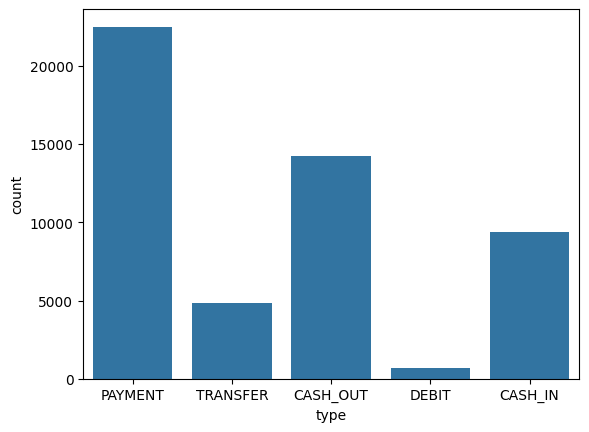

In [ ]:
sns.countplot(x='type', data=data)

Use the bar plot for analyzing Type and amount column also.

<Axes: xlabel='type', ylabel='amount'>

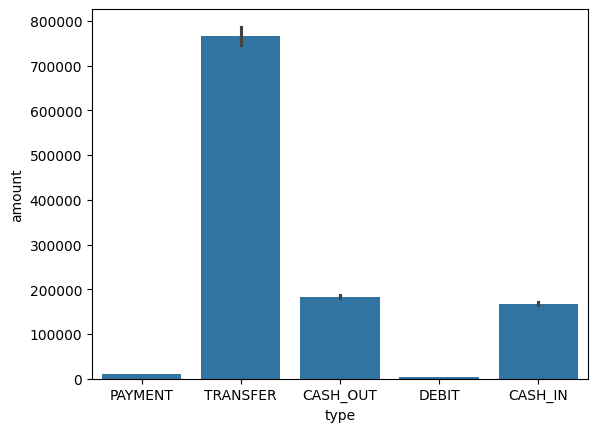

In [ ]:
sns.barplot(x='type', y='amount', data=data)

Both the graph clearly shows that mostly the type cash_out and transfer are maximum in count and as well as in amount.

Display the distribution of data among both the prediction values.



In [ ]:
data['isFraud'].value_counts()

,count
isFraud,
0,51523
1,100


Display the distribution of the step column using distplot.

<Figure size 1500x600 with 0 Axes>

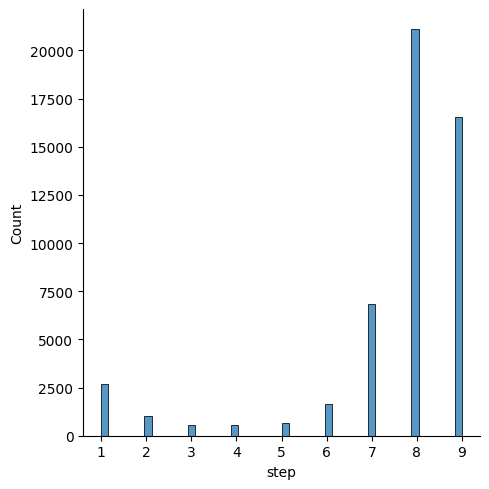

In [ ]:
plt.figure(figsize=(15, 6))
sns.displot(data['step'], bins=50)

Display the correlation among different features using Heatmap.

<Axes: >

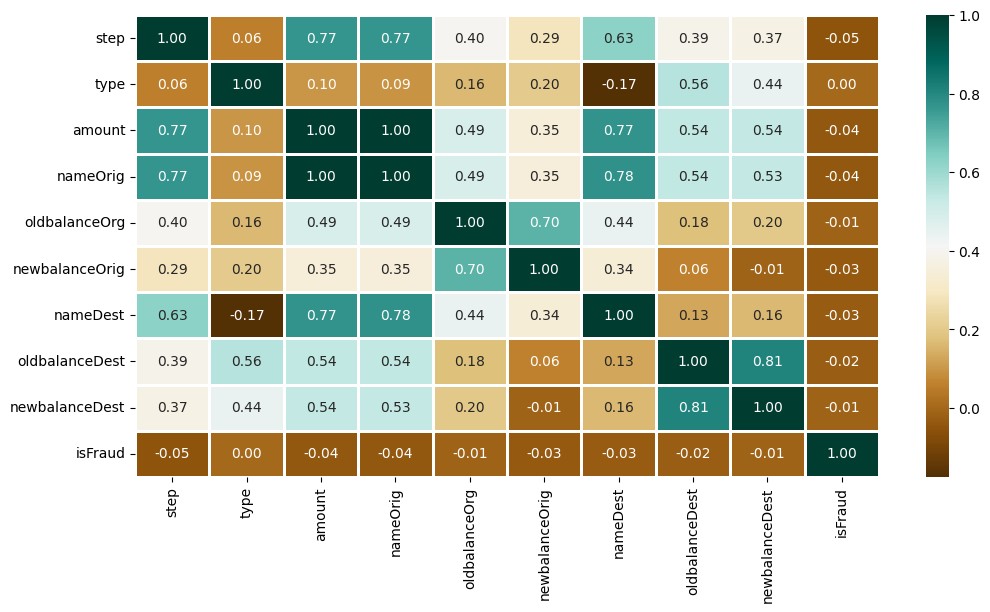

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.apply(lambda x: pd.factorize(x)[0]).corr(),
			cmap='BrBG',
			fmt='.2f',
			linewidths=2,
			annot=True)

Data Preprocessing
In This step includes the following :

Encoding of Type column

Dropping irrelevant columns like nameOrig, nameDest

Data Splitting

In [ ]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,False,False,True,False


In [ ]:
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']

In [ ]:
X.shape, y.shape

((51623, 10), (51623,))

Now let's split the data into 2 parts : Training and Testing.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

LabelEncoder → Converts categorical labels into numbers

StandardScaler → Normalizes data (important for ML models)

train_test_split → Splits data into training & testing sets

SMOTE → Handles class imbalance by generating synthetic samples

In [ ]:
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler)
from sklearn.model_selection import (
    train_test_split)
from imblearn.over_sampling import SMOTE

Converts categorical column type into multiple binary columns

In [ ]:
type_new1 = pd.get_dummies(data['type'], drop_first=True)
data_new1 = pd.concat([data, type_new1], axis=1)
data_new1.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,False,False,True,False


Converts original type column into numeric labels:

In [ ]:
le = LabelEncoder()
data_new1['type'] = le.fit_transform(data_new1['type'])

# Drop ID columns
data_new1.drop(['nameOrig','nameDest'],
         axis=1, inplace=True)

# Features & target
X = data_new1.drop('isFraud', axis=1)
y = data_new1['isFraud']

# Scale numeric features, Standardizes data using formula (Feature Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Train-test split (stratified)
X_tr,X_te,y_tr,y_te = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y)
#random_state=42 → ensures reproducibility
#stratify=y → keeps same fraud/non-fraud ratio in both sets
# SMOTE on training data only
sm = SMOTE(random_state=42)
X_res,y_res = sm.fit_resample(X_tr,y_tr)

print("Before SMOTE:", dict(
    zip(*np.unique(y_tr,return_counts=True))))
print("After SMOTE: ", dict(
    zip(*np.unique(y_res,return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(41218), np.int64(1): np.int64(80)}
After SMOTE:  {np.int64(0): np.int64(41218), np.int64(1): np.int64(41218)}


Importing the modules of relevent models.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

After importing, train the models.

In [39]:
models = [
    LogisticRegression(max_iter=2000),
    DecisionTreeClassifier(max_depth=7, random_state=42),
    RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)
]

for model in models:
    model.fit(X_res, y_res)   # ✅ use SMOTE data here
    print(f'{model} : ')

    train_preds = model.predict_proba(X_res)[:, 1]   # ✅ training on SMOTE
    print('Training Accuracy : ', ras(y_res, train_preds))

    y_preds = model.predict_proba(X_te)[:, 1]        # ✅ test data remains SAME
    print('Validation Accuracy : ', ras(y_te, y_preds))
    print()

LogisticRegression(max_iter=2000) : 
Training Accuracy :  0.9868973625442602
Validation Accuracy :  0.9391848617176127

DecisionTreeClassifier(max_depth=7, random_state=42) : 
Training Accuracy :  0.9946444514002739
Validation Accuracy :  0.829677341096555

RandomForestClassifier(criterion='entropy', n_estimators=7, random_state=7) : 
Training Accuracy :  0.9999999888164477
Validation Accuracy :  0.973403687530325



In [ ]:
from sklearn.metrics import roc_auc_score as ras

train_scores = []
val_scores = []
model_names = []

models = [
    LogisticRegression(max_iter=2000),
    DecisionTreeClassifier(max_depth=7, random_state=42),
    RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)
]

for model in models:
    model.fit(X_res, y_res)

    name = model.__class__.__name__
    model_names.append(name)

    print(f'{model} : ')

    train_preds = model.predict_proba(X_res)[:, 1]
    train_score = ras(y_res, train_preds)
    train_scores.append(train_score)
    print('Training ROC-AUC : ', train_score)

    y_preds = model.predict_proba(X_te)[:, 1]
    val_score = ras(y_te, y_preds)
    val_scores.append(val_score)
    print('Validation ROC-AUC : ', val_score)
    print()

LogisticRegression(max_iter=2000) : 
Training ROC-AUC :  0.9868973625442602
Validation ROC-AUC :  0.9391848617176127

DecisionTreeClassifier(max_depth=7, random_state=42) : 
Training ROC-AUC :  0.9946444514002739
Validation ROC-AUC :  0.829677341096555

RandomForestClassifier(criterion='entropy', n_estimators=7, random_state=7) : 
Training ROC-AUC :  0.9999999888164477
Validation ROC-AUC :  0.973403687530325



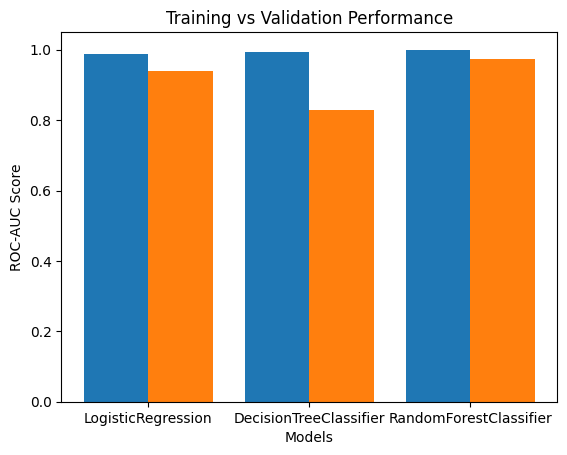

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(model_names))

plt.figure()
plt.bar(x - 0.2, train_scores, width=0.4)
plt.bar(x + 0.2, val_scores, width=0.4)

plt.xticks(x, model_names)
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Training vs Validation Performance")

plt.show()

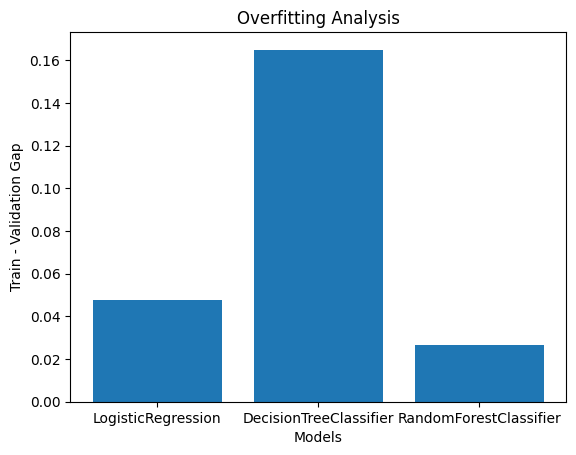

In [ ]:
diff = np.array(train_scores) - np.array(val_scores)

plt.figure()
plt.bar(model_names, diff)

plt.xlabel("Models")
plt.ylabel("Train - Validation Gap")
plt.title("Overfitting Analysis")

plt.show()

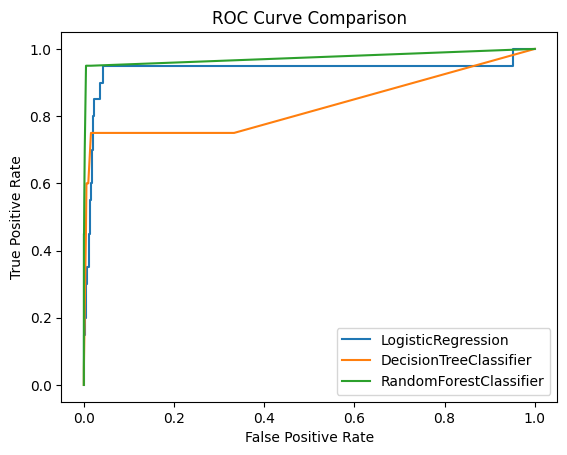

In [ ]:
from sklearn.metrics import roc_curve

plt.figure()

for model in models:
    y_probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_probs)
    plt.plot(fpr, tpr, label=model.__class__.__name__)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

The best-performed model is Random forest.

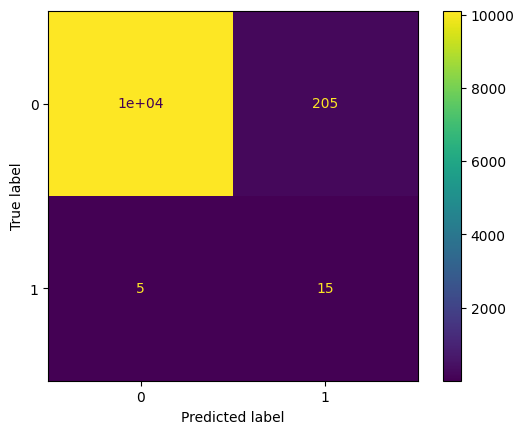

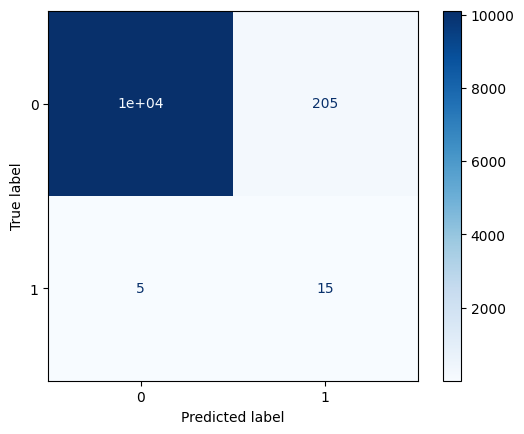

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_estimator(models[1], X_te, y_te)

cm.plot(cmap='Blues')

plt.show()

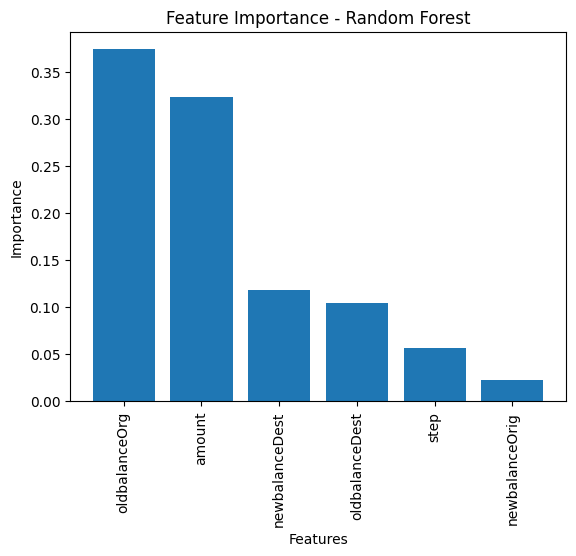

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv(filepath)

# Features & Target
X = df.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance = rf.feature_importances_
features = X.columns

# Sort values
indices = importance.argsort()[::-1]

# Plot
plt.figure()
plt.bar(range(len(features)), importance[indices])
plt.xticks(range(len(features)), features[indices], rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

# Save image
plt.savefig("feature_importance.png")

plt.show()

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid=lr_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

lr_grid.fit(X_res, y_res)

print("Best Logistic Regression Params:", lr_grid.best_params_)
print("Best Score:", lr_grid.best_score_)

Best Logistic Regression Params: {'C': 10, 'solver': 'liblinear'}
Best Score: 0.9888388378014522


In [ ]:
dt_params = {
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

dt_grid.fit(X_res, y_res)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Score:", dt_grid.best_score_)

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}
Best Score: 0.9983577062603336


In [34]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_res, y_res)

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

Best Random Forest Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Score: 0.9999957064196611
